In [1]:
import polars as pl
import numpy as np
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import statsmodels.api as stm
import scipy.stats as st
from matplotlib.colors import Normalize
from datetime import datetime as dt


from piepy.psychophysics.wheel.detection.wheelDetectionExperimentHub import WheelDetectionExperimentHub
from piepy.core.data_functions import make_subsets
from piepy.plotters.plotting_utils import set_style
from piepy.psychophysics.wheel.detection.wheelDetectionGroupedAggregator import WheelDetectionGroupedAggregator

In [2]:
DATA_PATH = Path.cwd().parents[0] / "260410_Ncomm_inhibition_data.parquet"

In [3]:
hub = WheelDetectionExperimentHub()
# load from session list
# hub.set_data(all_sessions,
#              load_sessions=True,
#              make_summary=True)
# hub.data.write_parquet("250206_experiment_data.parquet")

# load from saved data
all_data = pl.read_parquet(DATA_PATH)
hub.set_data(all_data,
             load_sessions=True,
             make_summary=True)

animalid,area,stimulus_count,stim_combination,opto_targets,isTitrated,isCNO,total_trials,stim_type,experiment_count,date,session_ids,stat_total_trial_count,stat_early_trial_count,stat_stim_trial_count,stat_correct_trial_count,stat_miss_trial_count,stat_catch_trial_count,stat_opto_trial_count,stat_opto_ratio,stat_nonopto_hit_rate,stat_correct_rate,stat_hit_rate,stat_false_alarm_rate,stat_nogo_rate,stat_median_response_time,stat_median_reaction_time,stat_d_prime,stat_easy_trial_count,stat_easy_hit_rate,stat_easy_nogo_rate,stat_easy_median_response_time,stat_easy_median_reaction_time
str,str,i32,str,i32,bool,bool,u32,list[str],u32,list[date],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i32],list[f64],list[f64],list[f64],list[f64]
"""KC139""","""AL""",1,"""0.04cpd_8.0Hz""",1,false,false,341,"[""0.04cpd_8.0Hz""]",1,[2022-10-18],[5216356],[341],[106],[213],[134],[79],[22],[80],[23.46],[69.925],[39.296],[62.911],[31.085],[37.089],[282.0],[177.6],[0.82294],[69],[98.551],[1.449],[266.0],[166.1]
"""KC139""","""AM""",1,"""0.04cpd_8.0Hz""",1,false,false,327,"[""0.04cpd_8.0Hz""]",1,[2022-11-08],[4297397],[327],[99],[213],[129],[84],[15],[79],[24.159],[66.418],[39.45],[60.563],[30.275],[39.437],[300.0],[178.6],[0.784455],[65],[90.769],[9.231],[282.0],[163.6]
"""KC139""","""LM""",1,"""0.04cpd_8.0Hz""",1,false,false,849,"[""0.04cpd_8.0Hz""]",1,[2022-11-01],[6503303],[849],[267],[536],[445],[91],[46],[177],[20.848],[95.822],[52.415],[83.022],[31.449],[16.978],[282.0],[171.3],[1.438198],[187],[98.93],[1.07],[249.0],[147.0]
"""KC139""","""PM""",1,"""0.04cpd_8.0Hz""",1,false,false,836,"[""0.04cpd_8.0Hz""]",1,[2022-11-16],[2940665],[836],[331],[463],[369],[94],[42],[155],[18.541],[86.039],[44.139],[79.698],[39.593],[20.302],[299.0],[196.2],[1.094779],[142],[100.0],[0.0],[265.0],[163.8]
"""KC139""","""RL""",1,"""0.04cpd_8.0Hz""",1,false,false,342,"[""0.04cpd_8.0Hz""]",1,[2022-10-25],[3884121],[342],[162],[164],[109],[55],[16],[54],[15.789],[70.909],[31.871],[66.463],[47.368],[33.537],[300.0],[187.9],[0.491155],[50],[96.0],[4.0],[282.0],[171.9]
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""KC152""","""V1retino""",1,"""0.04cpd_8.0Hz""",2,false,false,512,"[""0.04cpd_8.0Hz""]",1,[2024-08-26],[4243291],[512],[92],[380],[134],[246],[40],[117],[22.852],[41.445],[26.172],[35.263],[17.969],[64.737],[366.0],[251.6],[0.538317],[135],[61.481],[38.519],[350.0],[224.8]
"""KC152""","""dorsal""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,674,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",1,[2024-08-18],[4233727],[674],[192],[433],[248],[185],[49],[134],[19.881],[71.237],[36.795],[57.275],[28.487],[42.725],[333.0],[215.6],[0.751814],[151],[92.715],[7.285],[283.0],[182.9]
"""KC152""","""dorsal""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,true,550,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",1,[2024-08-19],[9727223],[550],[71],[428],[155],[273],[51],[157],[28.545],[52.03],[28.182],[36.215],[12.909],[63.785],[366.0],[256.2],[0.777985],[155],[72.258],[27.742],[349.5],[233.6]


In [4]:
areas = ["V1", "HVA","dorsal", "ventralPM"]
stim_combination = "0.04cpd_8.0Hz+0.16cpd_0.5Hz"
all_data = {}
big_df = pl.DataFrame()
for a in areas:
    df = hub.filter_by_areas(a,
                        strict_performance=True,
                        stim_combination=stim_combination,
                        isCNO=False)
    
    valid_sesh_ids = []
    for filt_tup in make_subsets(df,["session_id"]):
        filt_df = filt_tup[-1]
        if 1.0 not in filt_df["contrast"].to_list() and 0.0625 not in filt_df["contrast"].to_list():
            print(filt_tup[0],filt_df["contrast"].unique().to_list())
            print(filt_df.filter(pl.col("session_id")==filt_tup[0])[0,"session_path"])
            valid_sesh_ids.append(filt_tup[0]) 
        else:
            pass   
    dff = df.filter(pl.col("session_id").is_in(valid_sesh_ids))
    big_df = pl.concat([big_df,dff])
    all_data[a] = dff
hub.make_summary_data(big_df)

KC151_V1 doesn't have a session with hit rate >=75 and stim_trial_count>=300, removing...
KC151_V1 doesn't have a session with hit rate >=75 and stim_trial_count>=300, removing...
136869 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/230726_KC143_detect_opto120_V1__no_cam_KC
2260747 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/230726_KC146_detect_opto120_V1__no_cam_KC
3049271 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/240816_KC152_detect_opto120_V1__no_cam_KC
4091579 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/240312_KC147_detect_opto120_V1__1P_KC
6174456 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/240312_KC148_detect_opto120_V1__1P_KC
7159163 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/230726_KC145_detect_opto120_V1__no_cam_KC
7697023 [None, 0.0, 0.125, 0.5]
/Users/kaan/data/presentation/240312_KC149_detect_opto120_V1__1P_KC
KC149_HVA doesn't have a session with hit rate >=75 and stim_trial_count>=300, removing...
539813 [None, 

animalid,area,stimulus_count,stim_combination,opto_targets,isTitrated,isCNO,total_trials,stim_type,experiment_count,date,session_ids,stat_total_trial_count,stat_early_trial_count,stat_stim_trial_count,stat_correct_trial_count,stat_miss_trial_count,stat_catch_trial_count,stat_opto_trial_count,stat_opto_ratio,stat_nonopto_hit_rate,stat_correct_rate,stat_hit_rate,stat_false_alarm_rate,stat_nogo_rate,stat_median_response_time,stat_median_reaction_time,stat_d_prime,stat_easy_trial_count,stat_easy_hit_rate,stat_easy_nogo_rate,stat_easy_median_response_time,stat_easy_median_reaction_time
str,str,i32,str,i32,bool,bool,u32,list[str],u32,list[date],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[i32],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i32],list[f64],list[f64],list[f64],list[f64]
"""KC143""","""HVA""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,375,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",1,[2023-06-21],[1513764],[375],[122],[231],[123],[108],[22],[115],[30.667],[97.414],[32.8],[53.247],[32.533],[46.753],[299.0],[197.8],[0.534326],[49],[97.959],[2.041],[259.5],[167.0]
"""KC143""","""V1""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,822,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",1,[2023-07-26],[136869],[822],[448],[328],[244],[84],[46],[160],[19.465],[91.667],[29.684],[74.39],[54.501],[25.61],[356.5],[195.6],[0.542352],[91],[97.802],[2.198],[333.0],[184.8]
"""KC143""","""dorsal""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,850,"[""0.04cpd_8.0Hz"", ""0.16cpd_0.5Hz""]",1,[2023-04-13],[6843386],[850],[378],[416],[254],[162],[56],[169],[19.882],[79.352],[29.882],[61.058],[44.471],[38.942],[366.0],[232.7],[0.419869],[124],[93.548],[6.452],[319.0],[206.1]
"""KC143""","""ventralPM""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,656,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",1,[2023-06-13],[9128749],[656],[194],[417],[258],[159],[45],[187],[28.506],[84.348],[39.329],[61.871],[29.573],[38.129],[399.0],[230.0],[0.838816],[111],[90.991],[9.009],[383.0],[213.8]
"""KC144""","""dorsal""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,818,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",1,[2023-04-13],[8813198],[818],[522],[256],[187],[69],[40],[118],[14.425],[87.681],[22.861],[73.047],[63.814],[26.953],[249.0],[166.6],[0.260744],[72],[97.222],[2.778],[232.0],[157.9]
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""KC151""","""ventralPM""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,591,"[""0.16cpd_0.5Hz"", ""0.04cpd_8.0Hz""]",1,[2024-08-26],[8476922],[591],[158],[378],[167],[211],[55],[141],[23.858],[56.962],[28.257],[44.18],[26.734],[55.82],[332.0],[228.0],[0.474471],[116],[75.0],[25.0],[300.0],[201.2]
"""KC152""","""HVA""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,656,"[""0.04cpd_8.0Hz"", ""0.16cpd_0.5Hz""]",1,[2024-08-17],[4628394],[656],[179],[424],[226],[198],[53],[143],[21.799],[72.598],[34.451],[53.302],[27.287],[46.698],[316.0],[203.6],[0.687019],[138],[95.652],[4.348],[283.0],[178.6]
"""KC152""","""V1""",2,"""0.04cpd_8.0Hz+0.16cpd_0.5Hz""",1,false,false,599,"[""0.04cpd_8.0Hz"", ""0.16cpd_0.5Hz""]",1,[2024-08-16],[3049271],[599],[164],[389],[220],[169],[46],[139],[23.205],[75.2],[36.728],[56.555],[27.379],[43.445],[307.0],[194.2],[0.766446],[135],[91.852],[8.148],[267.0],[173.6]


In [5]:
@np.vectorize
def lenient_div(num: np.ndarray, den: np.ndarray) -> np.ndarray:
    """returns the numerator if denominator is zero, otherwise does regular division

    Args:
        num (Number | np.ndarray): Numerator
        den (Number | np.ndarray): Denominator

    Returns:
        Number | np.ndarray: Division result
    """
    return float(den and num / den or num)

 >WARNING< There are unused outcome values ['hit', 'miss'] vs ['miss', 'early', 'hit']


/Users/kaan/code/ncomm_piepy/piepy/.venv/lib/python3.10/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/Users/kaan/code/ncomm_piepy/piepy/.venv/lib/python3.10/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


0.04cpd_8.0Hz
HVA
V1
dorsal
ventralPM

['HVA', 'V1', 'dorsal', 'ventralPM']
HVA
V1
dorsal
ventralPM

['HVA', 'V1', 'dorsal', 'ventralPM']
0.16cpd_0.5Hz
HVA
V1
dorsal
ventralPM

['HVA', 'V1', 'dorsal', 'ventralPM']
HVA
V1
dorsal
ventralPM

['HVA', 'V1', 'dorsal', 'ventralPM']
0.04cpd_8.0Hz
[[ 81.90450005   5.46712744  66.83333333 127.08705328   6.        ]
 [ 85.96550992   4.52606449 199.3         45.26088819   7.        ]
 [ 72.60807687   5.0375892   97.41111111  42.92685783   9.        ]
 [ 69.6184447    6.1608129  121.08888889  61.37788564   9.        ]]
0.04cpd_8.0Hz
[[ 62.95624796   8.62456633 278.61666667  54.79635887   6.        ]
 [ 33.16676181  10.04061299 207.32857143  37.74197937   7.        ]
 [ 14.29848832   3.12903008 116.02222222  27.72165608   9.        ]
 [  9.8684026    1.58580914  74.86666667  10.22272795   9.        ]]
0.16cpd_0.5Hz
[[ 49.86883039  19.7268105  154.88333333  59.6777648    6.        ]
 [ 49.74974428  14.50655034 139.56666666  43.86737335   7.        ]


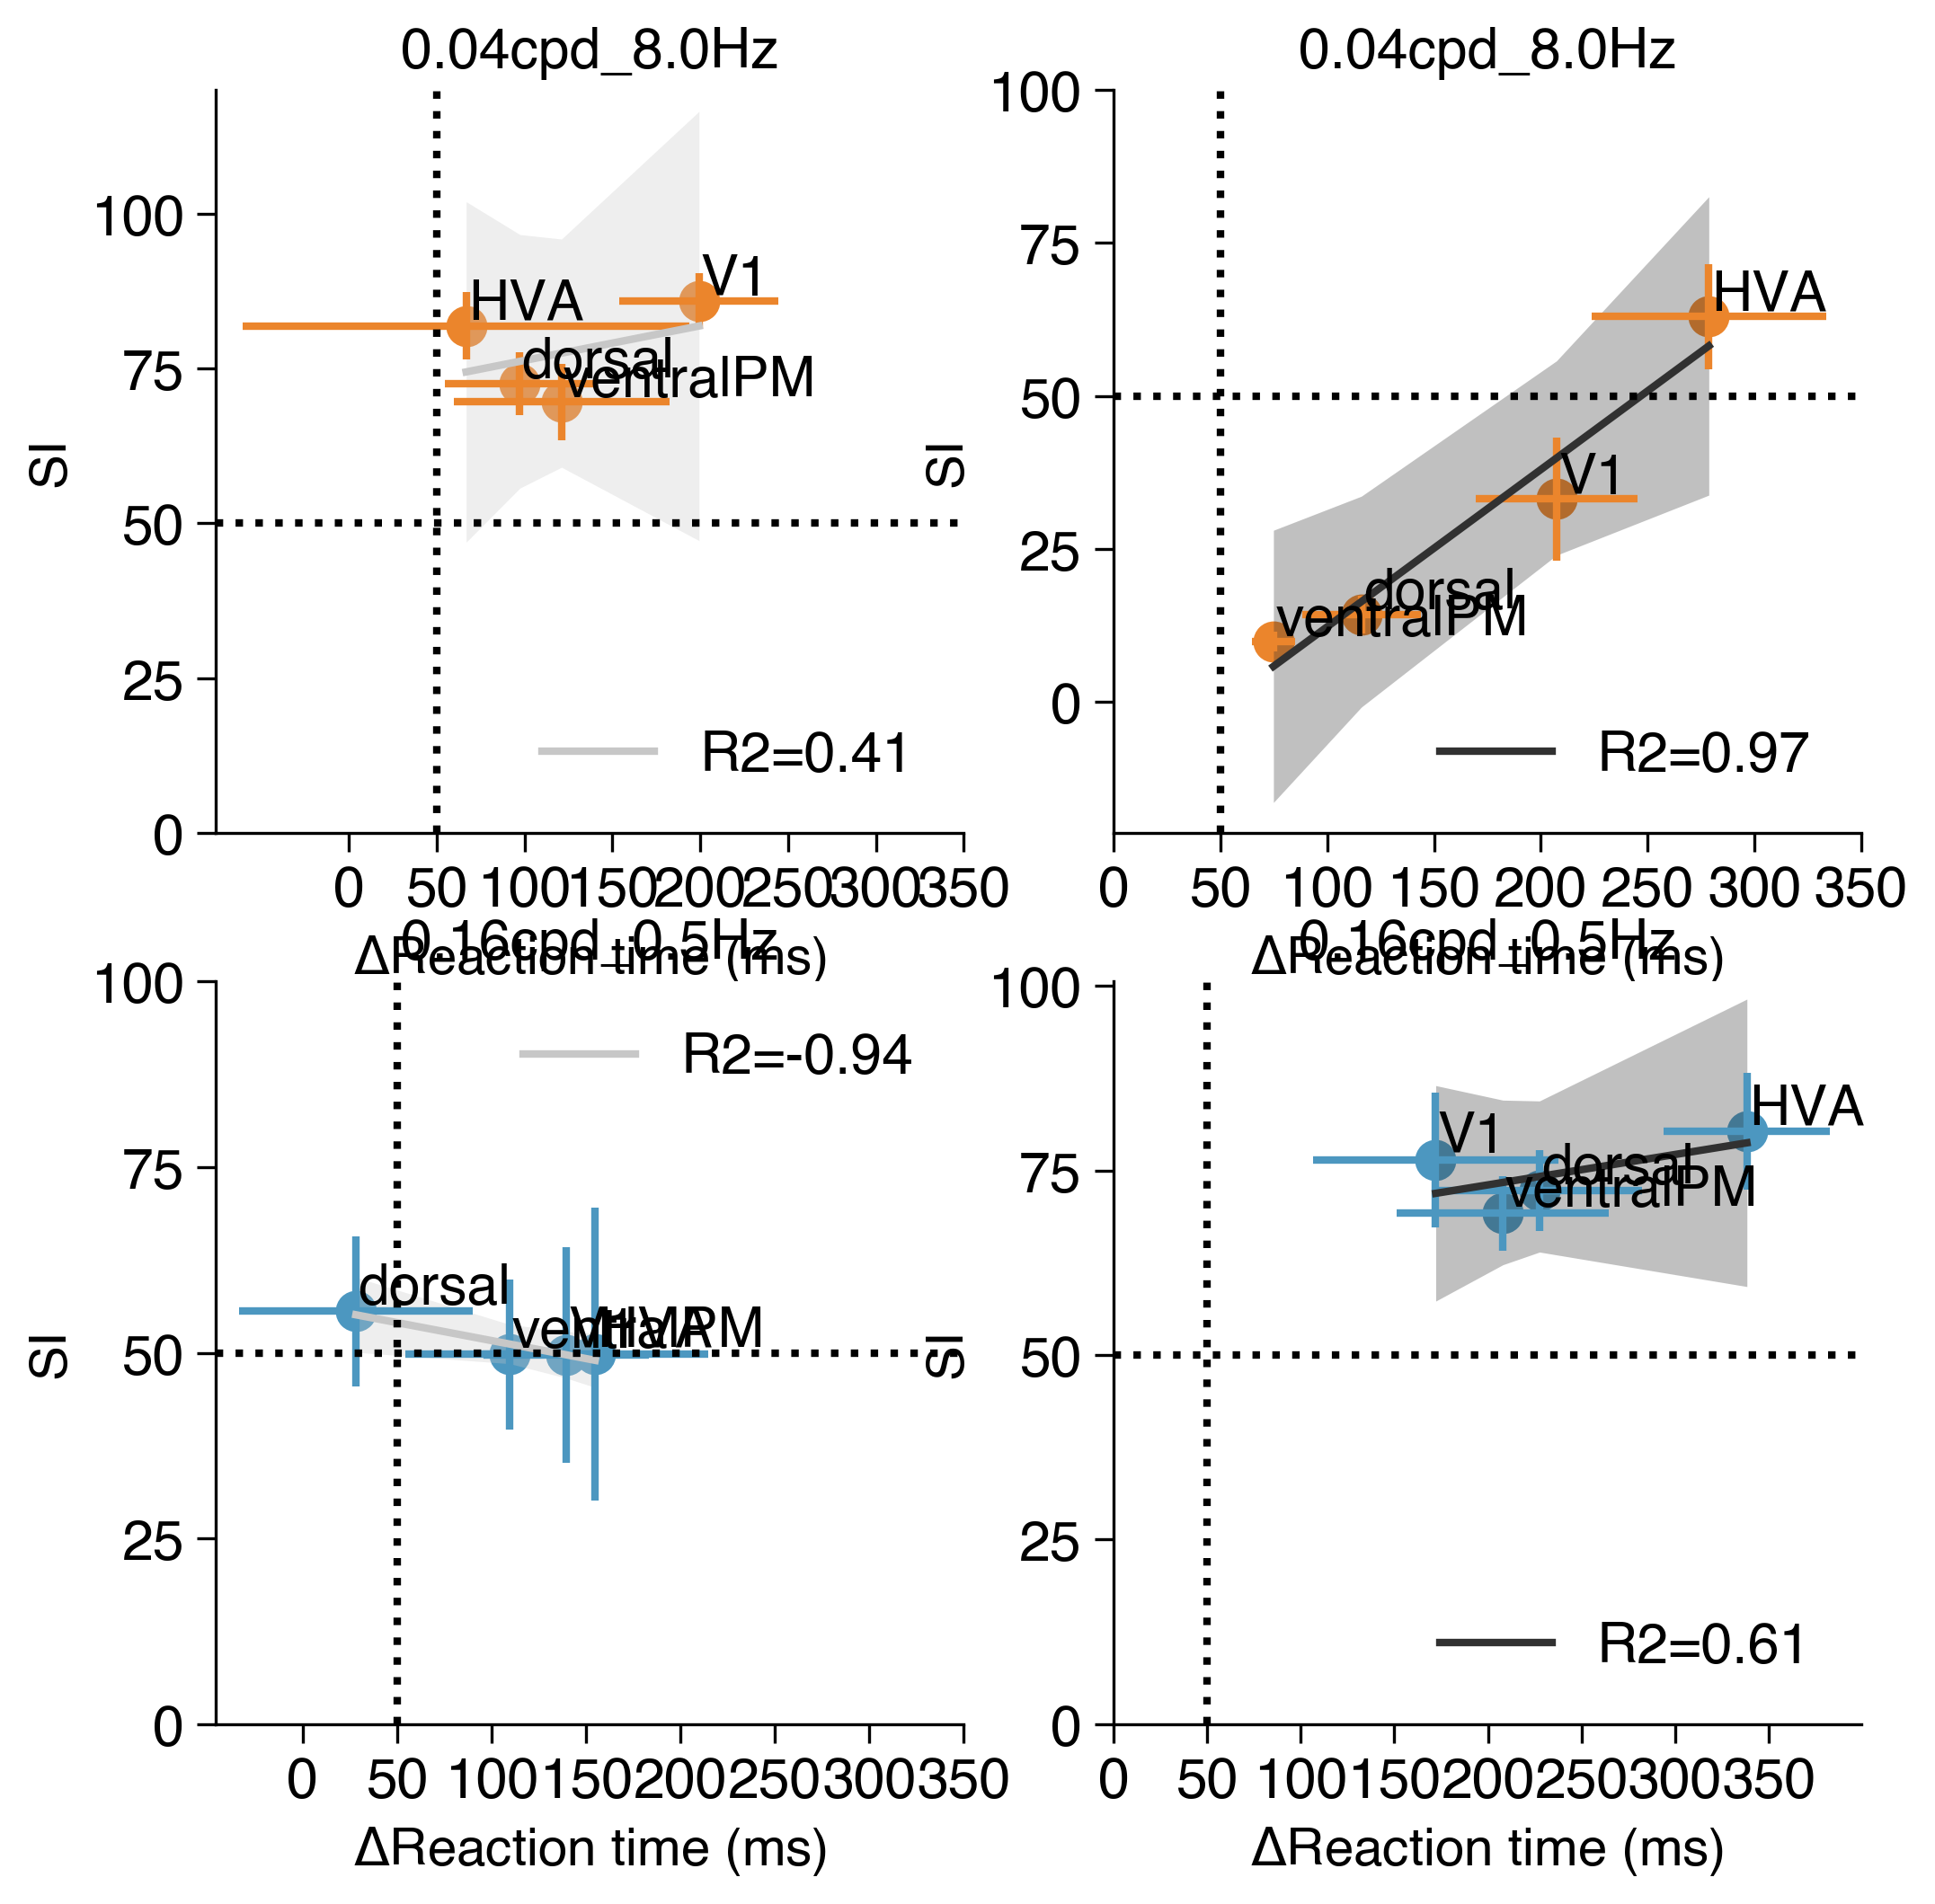

In [7]:
SFTF_COLORS = {"0.04cpd_8.0Hz":"#EB852C",
               "0.16cpd_0.5Hz":"#4C97C0"}

cmm = 1/2.54
set_style("print")
f,axs = plt.subplots(2,2,
                    figsize=(20*cmm,20*cmm))

do_bsi = True
do_norm_delta_rt = True

# colormap stuff
cmap = "viridis"
normalizer = Normalize(5, 10)
im = cm.ScalarMappable(norm=normalizer, cmap=cmap)

aggregator = WheelDetectionGroupedAggregator()
aggregator.set_data(data=big_df)
aggregator.group_data(group_by = ["contrast", 
                                  "stim_type", 
                                  "stim_side", 
                                  "area", 
                                  "animalid", 
                                  "opto_pattern"])
aggregator.calculate_hit_rates()
aggregator.calculate_opto_pvalues()

plot_data = aggregator.grouped_data.drop_nulls("contrast").filter(pl.col("stim_side")!="ipsi")
plot_data = plot_data.filter(pl.col("contrast").is_in([0.125, 0.5]))

# manually add baselines by joining
# catch_trials = plot_data.filter(
#     (pl.col("contrast") == 0) & (pl.col("opto_pattern") == -1)
# ).select(["animalid", "area", "contrast", "opto_pattern", "hit_count", "count"])
# # get baseline_hr
# catch_trials = catch_trials.with_columns(
#     (pl.col("hit_count") / pl.col("count")).alias("baseline_hr")
# )

# plot_data = plot_data.join(
#         catch_trials.select(["animalid", "area", "baseline_hr"]),
#         how="inner",
#         left_on=["animalid", "area"],
#         right_on=["animalid", "area"],
#     )
stim_types = ["0.04cpd_8.0Hz","0.16cpd_0.5Hz"]
val_dict = {}
for s in stim_types:
    stim_data = plot_data.filter(pl.col("stim_type")==s)
    
    val_mat = np.zeros((stim_data.n_unique('area'),         # areas [V1, HVA, dorsal, ventralPM]
                        5,                                  # [mean_hr,sem_hr,mean_rt,sem_rt,n_animal]
                        stim_data.n_unique(['contrast'])))  # contrasts[0.125,0.5]
    val_mat[:] = np.nan
    print(s)
    for filt_tup in make_subsets(stim_data,["contrast"],start_enumerate=0):
        filt_df = filt_tup[-1]
        aid_arr = []
        for area_tup in make_subsets(filt_df, ["area"], start_enumerate=0):
            print(area_tup[1])
            area_df = area_tup[-1]
            aid_arr.append(area_tup[1])
            hr_arr = []
            rt_arr = []
            for stim_tup in make_subsets(area_df,["animalid"],start_enumerate=0):
                stim_df = stim_tup[-1].sort(["opto_pattern"])
                
                if not do_bsi:
                    hr = 100*(stim_df[1,"hit_rate"] - stim_df[0,"hit_rate"])
                else:
                    _top = stim_df[0,"hit_rate"] - stim_df[1,"hit_rate"]
                    hr = 100*lenient_div(_top, stim_df[0,"hit_rate"])
                
                opto_hit_count = stim_df[1,"hit_count"]
                if not do_norm_delta_rt:
                    if stim_df[1,"median_hit_reaction_times"] is not None:
                        delta_rt = stim_df[1,"median_hit_reaction_times"] - stim_df[0,"median_hit_reaction_times"]
                    else:
                        delta_rt = np.nan
                else:
                    if stim_df[1,"median_hit_reaction_times"] is not None:
                        _top = stim_df[1,"median_hit_reaction_times"] - stim_df[0,"median_hit_reaction_times"]
                        # _bottom = 1000 - stim_df[0,"median_hit_reaction_times"]
                        # delta_rt = 100*lenient_div(_top, _bottom)
                        delta_rt = stim_df[1,"median_hit_reaction_times"] - stim_df[0,"median_hit_reaction_times"]
                    else:
                        delta_rt = np.nan
                    
                hr_arr.append(hr)
                rt_arr.append(delta_rt)

            # take average
            mean_hr = np.nanmean(hr_arr)
            mean_rt = np.nanmean(rt_arr)
            sem_hr = st.sem(hr_arr,nan_policy="omit")
            sem_rt = st.sem(rt_arr,nan_policy="omit")

            val_mat[area_tup[0],:,filt_tup[0]] = [mean_hr,sem_hr,mean_rt,sem_rt,area_df.n_unique("animalid")]
        print()
        print(aid_arr)
    val_dict[s] = val_mat


c = ["#C7C7C7", "#313131"]
for ii,skey in enumerate(val_dict.keys()):
    v = val_dict[skey]
    ax_row = axs[ii]
    for d in range(v.shape[2]):
        contrast_slice = v[:,:,d]
        print(skey)
        print(contrast_slice)
        
        # sort 
        aid_arr_sorted = [aid_arr[ii] for ii in contrast_slice[:, 2].argsort()]
        contrast_slice = contrast_slice[contrast_slice[:, 2].argsort()]
        
        _rt = contrast_slice[:,2]
        _hr = contrast_slice[:,0]
        _sem_hr = contrast_slice[:,1]
        _sem_rt = contrast_slice[:,3]
        

        clr = [c[d] for _ in contrast_slice]
        ax_row[d].scatter(_rt,
                _hr,
                c=SFTF_COLORS[skey],
                linewidths=1)
        
        # sem hr
        ax_row[d].vlines(_rt,
                     ymin=_hr-_sem_hr,
                     ymax=_hr+_sem_hr,
                     colors=SFTF_COLORS[skey])

        # sem rt
        ax_row[d].hlines(_hr,
                     xmin=_rt-_sem_rt,
                     xmax=_rt+_sem_rt,
                     colors=SFTF_COLORS[skey])
        
        for ai, coord in enumerate(zip(_rt,_hr)):
            ax_row[d].text(coord[0]+1,coord[1]+1, aid_arr_sorted[ai])

        non_nan = np.invert(np.isnan(_rt))
        
        X = stm.add_constant(contrast_slice[non_nan,2])
        ols_model = stm.OLS(contrast_slice[non_nan,0], X)
        est = ols_model.fit()
        out = est.conf_int(alpha=0.05, cols=None)

        y_pred = est.predict(X)
        x_pred = contrast_slice[non_nan,2]
        slope, intercept, r_value, p_value, std_err = st.linregress(contrast_slice[non_nan,2], contrast_slice[non_nan,0])


        ax_row[d].plot(x_pred,y_pred,color=clr[0],label=f"R2={r_value:.2}")

        pred = est.get_prediction(X).summary_frame()
        
        ax_row[d].fill_between(x=x_pred,
                        y1=pred['mean_ci_lower'].tolist(),
                        y2=pred['mean_ci_upper'].tolist(),
                        linewidth=0,
                        color=clr[0],
                        alpha=0.3)
        
        # ax_row.plot(x_pred,pred['mean_ci_lower'],linestyle='--',color=clr[0])
        # ax_row.plot(x_pred,pred['mean_ci_upper'],linestyle='--',color=clr[0])
        ax_row[d].set_title(skey)
        ax_row[d].legend(frameon=False)
        ax_row[d].set_xlabel(r"$\Delta$Reaction time (ms)")
        ax_row[d].axhline(50,c="k",linestyle=":")
        
        ax_row[d].set_yticks([0,25,50,75,100])
        ax_row[d].axvline(50,c="k",linestyle=":")
        ax_row[d].set_xticks([0,50,100,150,200,250,300,350])
        if not do_bsi:
            ax_row[d].set_ylabel(r"$\Delta$Hit rate (%)")
        else:
            ax_row[d].set_ylabel("SI")